In [21]:
pip install scikit-learn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [8]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import joblib

**Part 1: Preparing the Data**
Before the model can learn I have to clean and organize the information.

##### Cleaning the Information
English Only: iltered out any data that wasn't in English so the model doesn't get confused by different languages.

##### Fixing Blanks:
Sometimes data is missing (empty cells). So I filled those blanks with empty text so the computer doesn't "crash" when it hits an empty spot.

##### Fair Testing:
Combined all data to make sure that when I split it into "Study Material" (Training) and "The Final Exam" (Testing), both sets have a fair mix of all categories.

**2. Translating Text into Numbers**
Computers cannot read words; they only understand numbers I used two main methods to "translate" our data:

*Word Importance (TF-IDF)*: This looks at the messages and gives higher scores to unique, meaningful words while ignoring common words like "the" or "and." It also looks at pairs of words (like "not working") so the AI understands context better.

*Category Tags:* For simple labels like "Priority" (High, Medium, Low) I turned them into a simple number code that the AI can easily digest.

**3. Setting up the "Learning Pipeline"**
Now that the data is in number format, prepare it for the AI engine (PyTorch):

##### The Tensors:
This is just a fancy word for "Organized Lists of Numbers. I converted the data into this format so the AI can process it at high speeds.

##### The Data Shuffler (DataLoader):
To make sure the AI doesn't just memorize the order of the data, I shuffle and feed the information in small batches. This helps the AI learn patterns rather than just memorizing the sequence.

In [9]:
set_config(transform_output='pandas')

# load dataset
train_df = pd.read_csv('train_dataset.csv', engine='python')
test_df = pd.read_csv('test_dataset.csv', engine='python')

# filter for english
train_en = train_df[train_df['language'] == 'en'].copy()
test_en = test_df[test_df['language'] == 'en'].copy()

# concatenate them into one full dataset.
full_dataset = pd.concat([train_en, test_en], axis=0, ignore_index=True)

tag_cols = list(full_dataset.columns[-8:])
full_dataset[tag_cols] = full_dataset[tag_cols].fillna("")

#. Combine the tag columns into a single text feature
full_dataset['tags_text'] = full_dataset[tag_cols].astype(str).agg(' '.join, axis=1)

#. Fill NaN values in the main text columns safely
text_fields = ['body', 'answer', 'subject']
full_dataset[text_fields] = full_dataset[text_fields].fillna('')

# create features and labels
X = full_dataset.drop(columns=['queue', 'language', 'version'])
y = full_dataset['queue']

# strasify labels
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

# vectorize data
preprocess = ColumnTransformer(
    transformers=[
        ("vec_body", TfidfVectorizer(max_features=10000, ngram_range=(1,4), stop_words='english', min_df=2), 'body'),
        ("vec_subj", TfidfVectorizer(max_features=200), 'subject'),
        ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['type'])
    ],
    n_jobs=-1,
    sparse_threshold=0
)

# run transformer
vectorized_training_data = preprocess.fit_transform(X_train_raw)
vectorized_testing_data = preprocess.transform(X_test_raw)

# encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

# turn them tensors
tensored_training_data=torch.from_numpy(vectorized_training_data.to_numpy()).float()
tensored_testing_data = torch.from_numpy(vectorized_testing_data.to_numpy()).float()
# turn labels into tensors
tensored_training_labels = torch.from_numpy(y_train_encoded).long()
tensored_testing_labels = torch.from_numpy(y_test_encoded).long()

# turns them tensors dataset
train_dataset = TensorDataset(tensored_training_data, tensored_training_labels)
test_dataset = TensorDataset(tensored_testing_data, tensored_testing_labels)

# create dataloader
train_data = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_data = DataLoader(test_dataset, batch_size=32, shuffle=False)

Part 2: Building the "AI Brain"
Now that the data is ready, I built the actual model. I designed a custom "Neural Network", that learn to recognize patterns in the data I prepared.

#### 1. Designing the Structure
The Input Layer: My model starts by looking at 16,207 different data points for every single entry

#### The Hidden Layers:
I built 4 layers for the model to think through. I started with a layer of 512 neurons narrowing down to 128 using the funnel method.

**2. Teaching the AI to Think Better**
To make sure the model learns correctly and doesn't just memorize the answers, I added three special features:

#### Leaky ReLU (The Activation):
This is the model’s "decision-making" rule helping the model decide which information is important enough to pass on to the next layer.

#### Batch Normalization (The Balancer):
This keeps the math stable,  which helps the model learn much faster.

#### Dropout (The Memory Guard):
This is my main tool to stop overfitting. Allows the model to learn instead of memorizing patterns.

**3. The Goal**.
By the time the data reaches the 4th and final layer, the model has condensed those 16,207 data points down into a final prediction—telling us exactly what kind of incident it is and how it should be handled.

In [10]:
from torch import nn
from tqdm.auto import tqdm
from timeit import default_timer as timer
from helper_functions import print_train_time
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, average_precision_score

In [11]:
from torch.nn.modules.activation import LeakyReLU
from torch.nn.modules import BatchNorm1d
class IncidentTrackingSystem(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_stack = nn.Sequential(
            # Input Layer, matching vectorizer output, wider than original but narrower than last attempt
            nn.Linear(10204, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.5), # Increased dropout to combat overfitting

            # Hidden Layer 1
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.5), # Increased dropout

            # Hidden Layer 2
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.5), # Increased dropout

            # Output Layer (10 classes)
            nn.Linear(128, 10)
        )

  def forward(self, x):
    return self.layer_stack(x)

**SETUP DEVICE AGNOSTIC CODE.** This automatically switches runtime type based on the runtime we're on. If we're on a GPU then it changes, if not it continues on the CPU

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
torch.manual_seed(42)
model = IncidentTrackingSystem().to(device)

**PHASE 2.1** Pick loss function and optimizer

I used CrossEntropyLoss because we're working a multiclass classifier project.

I used the AdamW because it handled weight_decay better and improved generalization.

I also made use of compute_class_weight from scikit learn to make the classes balanced so that the model doesn't become biased

In [14]:
weight_classes = np.unique(y_train_raw)
pos_weight = compute_class_weight(class_weight='balanced', classes=weight_classes, y=y_train_raw)
weights_tensor = torch.tensor(pos_weight, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-2) # Increased weight_decay

**PHASE 2.2** Test model before training

In [ ]:
from my_helper_functions import multiclass_testing_loop

testing_model = multiclass_testing_loop(
    model,
    test_data,
    loss_fn,
    device
)
testing_model

**PHASE 2.3** Build training and testing loop

In [16]:
from my_helper_functions import multiclass_training_loop, multiclass_testing_loop

In [17]:
epochs_list = []
training_list = []
testing_list = []

epochs = 24

train_start_time = timer()
for epoch in tqdm(range(epochs)):
  training_model = multiclass_training_loop(
      model, train_data, loss_fn, optimizer, device
  )
  testing_model = multiclass_testing_loop(
    model,
    test_data,
    loss_fn,
    device,

  )
  epochs_list.append(epochs)
  training_list.append(training_model)
  testing_list.append(testing_model)

train_end_time = timer()
print_train_time(train_start_time, train_end_time, device=next(model.parameters()).device)


  0%|          | 0/24 [00:00<?, ?it/s]

Train Loss: 1.9635 | Train acc: 0.2395 | Train recall: 43.1746 | Train precision: 29.9858 | Train ROC: 0.7114 | Train AUPRC: 0.2595
Accuracy score: 33.60 | Recall score: 50.50 | Test precision: 36.46 | F1 score: 29.61 | Roc auc score: 0.7960 | AUPRC: 0.4089
Train Loss: 1.4596 | Train acc: 0.3777 | Train recall: 57.7980 | Train precision: 39.3246 | Train ROC: 0.8298 | Train AUPRC: 0.4511
Accuracy score: 41.77 | Recall score: 57.43 | Test precision: 43.82 | F1 score: 38.62 | Roc auc score: 0.8435 | AUPRC: 0.5358
Train Loss: 1.0964 | Train acc: 0.4801 | Train recall: 67.3013 | Train precision: 49.2181 | Train ROC: 0.8865 | Train AUPRC: 0.6090
Accuracy score: 50.46 | Recall score: 61.47 | Test precision: 53.81 | F1 score: 47.71 | Roc auc score: 0.8740 | AUPRC: 0.6168
Train Loss: 0.8534 | Train acc: 0.5710 | Train recall: 73.7517 | Train precision: 57.3971 | Train ROC: 0.9220 | Train AUPRC: 0.7189
Accuracy score: 55.45 | Recall score: 65.78 | Test precision: 56.00 | F1 score: 50.76 | Roc au

306.8317247939999

**PHASE 4** EVALUATING model after training to see improvements

In [18]:
evaluation, all_classes, all_preds = multiclass_testing_loop(
    model,
    test_data,
    loss_fn,
    device
)
evaluation

Accuracy score: 72.41 | Recall score: 72.86 | Test precision: 75.31 | F1 score: 66.83 | Roc auc score: 0.9348 | AUPRC: 0.7804


1.391375831207313

Created a confusion matrix to visualize my model's prediction and spot classes where it did well and otherwise

<Figure size 2000x1500 with 0 Axes>

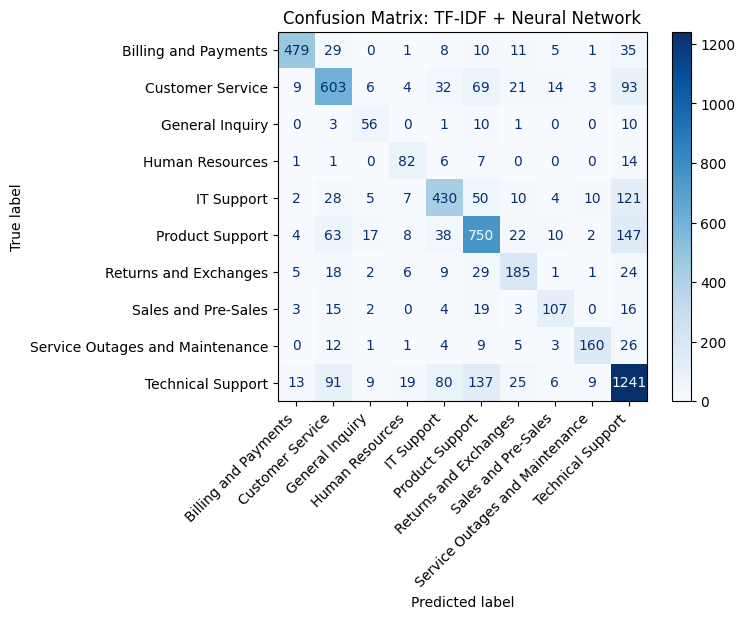

In [20]:

class_names = label_encoder.classes_
predicted_classes = [np.argmax(pred) for pred in all_preds]

cm = confusion_matrix(all_classes, predicted_classes)
plt.figure(figsize=(20, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: TF-IDF + Neural Network")
plt.xticks(rotation=45, ha='right')
plt.show()

Used classification to see how well my model performed on all classes and see it's probabilites for different evaluation metrics

In [21]:
predicted_classes = [np.argmax(pred) for pred in all_preds]
report_dict = classification_report(all_classes, predicted_classes, target_names=class_names, output_dict=True)

import pandas as pd
report_df = pd.DataFrame(report_dict).transpose()
print(report_df)


                                 precision    recall  f1-score     support
Billing and Payments              0.928295  0.827288  0.874886   579.00000
Customer Service                  0.698725  0.706089  0.702388   854.00000
General Inquiry                   0.571429  0.691358  0.625698    81.00000
Human Resources                   0.640625  0.738739  0.686192   111.00000
IT Support                        0.702614  0.644678  0.672400   667.00000
Product Support                   0.688073  0.706880  0.697350  1061.00000
Returns and Exchanges             0.653710  0.660714  0.657194   280.00000
Sales and Pre-Sales               0.713333  0.633136  0.670846   169.00000
Service Outages and Maintenance   0.860215  0.723982  0.786241   221.00000
Technical Support                 0.718587  0.761350  0.739351  1630.00000
accuracy                          0.724040  0.724040  0.724040     0.72404
macro avg                         0.717561  0.709421  0.711255  5653.00000
weighted avg             

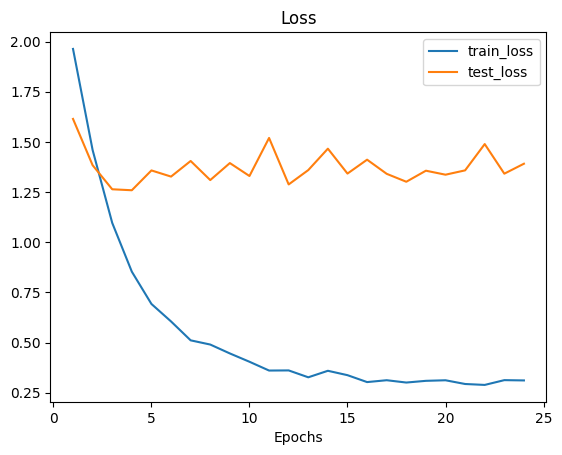

In [22]:
plot_training_loss = [item[0] for item in training_list]
plot_testing_loss = [item[0] for item in testing_list]

plot_epochs = list(range(1, len(plot_training_loss) + 1))

plt.plot(plot_epochs, plot_training_loss, label="train_loss")
plt.plot(plot_epochs, plot_testing_loss, label="test_loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.legend()


Save vectorizer so as not to transform each api request from the frontend everytime before retuning a response and label encoder so that during prediction, we're able to get the predicted class from the label encoder classes

In [23]:
joblib.dump(preprocess, "TfidfVectorizer.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")

['label_encoder.joblib']

In [24]:
torch.save(model.state_dict(), 'incident_tracking_system.pth')

In [25]:
params=torch.load('incident_tracking_system.pth')
model.load_state_dict(params)

<All keys matched successfully>